In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

In [12]:
trans_df = pd.read_csv(r"C:\Users\ayman\Documents\Github\fraud_detection\data\trans.csv", sep=";", low_memory=False)
loan_df  = pd.read_csv(r"C:\Users\ayman\Documents\Github\fraud_detection\data\loan.csv",  sep=";")

# Convert

In [13]:
# Convert YYMMDD format to proper datetime
trans_df["date"] = pd.to_datetime(trans_df["date"], format="%y%m%d")

print(trans_df["date"].min(), "→", trans_df["date"].max())
print(f"Total transactions: {len(trans_df):,}")
print(f"Unique accounts: {trans_df['account_id'].nunique():,}")
trans_df.dtypes

1993-01-01 00:00:00 → 1998-12-31 00:00:00
Total transactions: 1,056,320
Unique accounts: 4,500


trans_id               int64
account_id             int64
date          datetime64[ns]
type                  object
operation             object
amount               float64
balance              float64
k_symbol              object
bank                  object
account              float64
dtype: object

In [14]:
# Resample to monthly balance per account
monthly = (
    trans_df
    .groupby(["account_id", pd.Grouper(key="date", freq="ME")])
    .agg(
        monthly_spend   = ("amount",  "sum"),
        monthly_txn_cnt = ("amount",  "count"),
        end_balance     = ("balance", "last")
    )
    .reset_index()
)

monthly.head(10)

,account_id,date,monthly_spend,monthly_txn_cnt,end_balance
0,1,1995-03-31,1000.0,1,1000.0
1,1,1995-04-30,16298.2,3,17298.2
2,1,1995-05-31,5858.0,3,23156.2
3,1,1995-06-30,3979.6,3,26735.8
4,1,1995-07-31,9087.9,3,25223.7
5,1,1995-08-31,11292.8,4,21501.9
6,1,1995-09-30,6937.1,5,22105.8
7,1,1995-10-31,9136.1,5,20508.7
8,1,1995-11-30,9000.8,6,19906.2
9,1,1995-12-31,8364.6,6,18187.6


# Merge

In [18]:
# Bring in loan status (A/B/C/D) for each account
loan_df["date"] = pd.to_datetime(loan_df["date"], format="%y%m%d")

monthly_loans = monthly.merge(
    loan_df[["account_id", "status"]],
    on="account_id",
    how="inner")

# Focus on defaulted (B/D) vs good (A)
monthly_loans["defaulted"] = monthly_loans["status"].isin(["B", "D"]).astype(int)

monthly_loans.head()

,account_id,date,monthly_spend,monthly_txn_cnt,end_balance,status,defaulted
0,2,1993-02-28,1100.0,1,1100.0,A,0
1,2,1993-03-31,23949.5,3,25049.5,A,0
2,2,1993-04-30,31345.5,3,34394.9,A,0
3,2,1993-05-31,37980.7,3,37175.6,A,0
4,2,1993-06-30,52913.9,3,45289.5,A,0


# Plot 

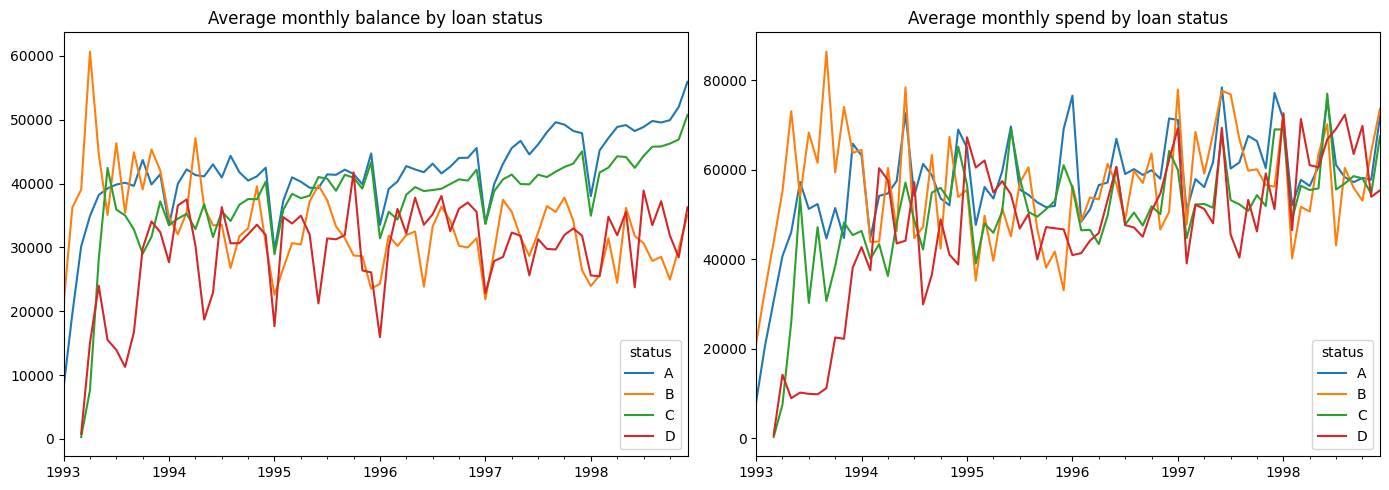

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average balance over time by loan status
monthly_loans.groupby(["date", "status"])["end_balance"].mean().unstack().plot(ax=axes[0])
axes[0].set_title("Average monthly balance by loan status")
axes[0].set_xlabel("")

# Average monthly spend
monthly_loans.groupby(["date", "status"])["monthly_spend"].mean().unstack().plot(ax=axes[1])
axes[1].set_title("Average monthly spend by loan status")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

In [19]:
# Engineer time-based features per account
features = monthly_loans.groupby("account_id").agg(
    balance_trend     = ("end_balance",     lambda x: np.polyfit(range(len(x)), x, 1)[0]),
    balance_volatility= ("end_balance",     "std"),
    avg_monthly_spend = ("monthly_spend",   "mean"),
    spend_volatility  = ("monthly_spend",   "std"),
    avg_txn_count     = ("monthly_txn_cnt", "mean")
).reset_index()

features.head()

,account_id,balance_trend,balance_volatility,avg_monthly_spend,spend_volatility,avg_txn_count
0,2,326.021630,10812.193682,44387.032394,12214.183873,6.732394
1,19,-566.818274,12447.026689,35011.464444,10198.577978,6.733333
2,25,52.843448,22245.209253,98618.170000,76945.517759,9.133333
3,37,-2042.566912,20327.330734,55773.758824,45691.781318,7.647059
4,38,257.885294,10111.318162,33644.100000,10842.008555,7.647059


In [20]:
# Engineer time-based features per account
features = monthly_loans.groupby("account_id").agg(
    balance_trend      = ("end_balance",     lambda x: np.polyfit(range(len(x)), x, 1)[0]),
    balance_volatility = ("end_balance",     "std"),
    avg_monthly_spend  = ("monthly_spend",   "mean"),
    spend_volatility   = ("monthly_spend",   "std"),
    avg_txn_count      = ("monthly_txn_cnt", "mean")
).reset_index()

features.head()

,account_id,balance_trend,balance_volatility,avg_monthly_spend,spend_volatility,avg_txn_count
0,2,326.021630,10812.193682,44387.032394,12214.183873,6.732394
1,19,-566.818274,12447.026689,35011.464444,10198.577978,6.733333
2,25,52.843448,22245.209253,98618.170000,76945.517759,9.133333
3,37,-2042.566912,20327.330734,55773.758824,45691.781318,7.647059
4,38,257.885294,10111.318162,33644.100000,10842.008555,7.647059


In [21]:
# Add defaulted label
loan_status = loan_df[["account_id", "status"]].copy()
loan_status["defaulted"] = loan_status["status"].isin(["B", "D"]).astype(int)

model_df = features.merge(loan_status, on="account_id", how="inner")
model_df.head()

,account_id,balance_trend,balance_volatility,avg_monthly_spend,spend_volatility,avg_txn_count,status,defaulted
0,2,326.021630,10812.193682,44387.032394,12214.183873,6.732394,A,0
1,19,-566.818274,12447.026689,35011.464444,10198.577978,6.733333,B,1
2,25,52.843448,22245.209253,98618.170000,76945.517759,9.133333,A,0
3,37,-2042.566912,20327.330734,55773.758824,45691.781318,7.647059,D,1
4,38,257.885294,10111.318162,33644.100000,10842.008555,7.647059,C,0


# Model

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

X = model_df.drop(columns=["account_id", "status", "defaulted"])
y = model_df["defaulted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=46, stratify=y
)

smote = SMOTE(random_state=46)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=46)
rf.fit(X_train_res, y_train_res)

test_preds = rf.predict(X_test)
print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

           0       0.94      0.89      0.92       152
           1       0.38      0.53      0.44        19

    accuracy                           0.85       171
   macro avg       0.66      0.71      0.68       171
weighted avg       0.88      0.85      0.86       171



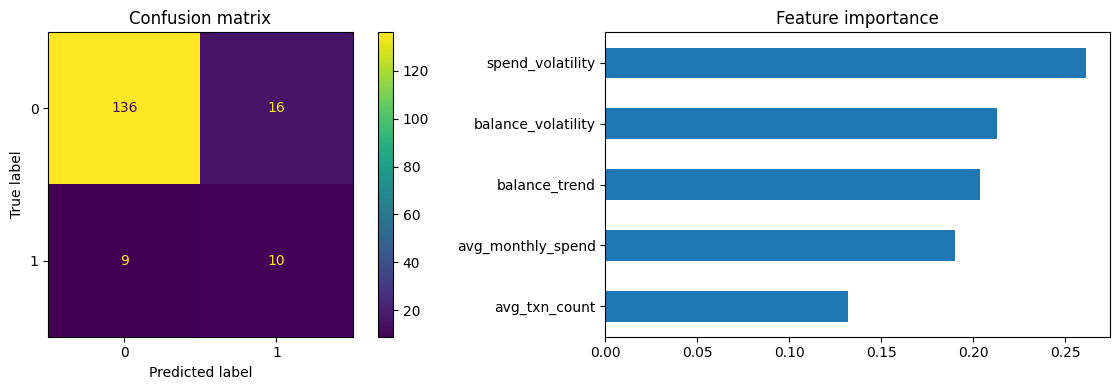

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, ax=axes[0])
axes[0].set_title("Confusion matrix")

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Feature importance")

plt.tight_layout()
plt.show()

In [ ]:
#Accounts that default show significantly higher spending and balance volatility over time. Erratic financial behavior is a stronger predictor of loan default than average spending amount alone.

# Score

In [24]:
from sklearn.metrics import accuracy_score, recall_score

print(f"Accuracy : {accuracy_score(y_test, test_preds):.3f}")
print(f"Recall   : {recall_score(y_test, test_preds):.3f}")
print()
print(classification_report(y_test, test_preds, target_names=["Good", "Default"]))

Accuracy : 0.854
Recall   : 0.526

              precision    recall  f1-score   support

        Good       0.94      0.89      0.92       152
     Default       0.38      0.53      0.44        19

    accuracy                           0.85       171
   macro avg       0.66      0.71      0.68       171
weighted avg       0.88      0.85      0.86       171

